# Comparison of Amplification methods using Majority Voting

Author: Nimitt \
Email: nimitt.nimitt@iitgn.ac.in

## Problem Statement

We have an algorithm $A$ for a decision problem with probability of success $p > 1/2$. We want to amplify success rate of $A$ to $q > p$. We achieve this by repeating algorithm $A$ with success rate of repeated algorithm given by various methods.

In [128]:
# Importing Libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom
from math import ceil, log, sqrt, exp
from scipy.stats import binom

## Chernoff Inequality

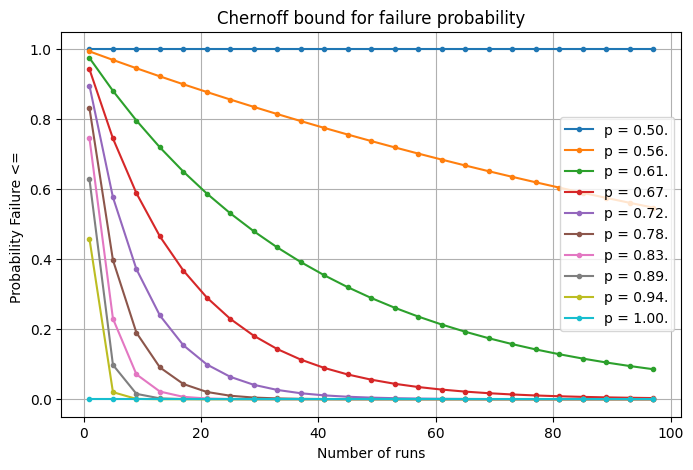

In [129]:
def chernoff(n, p):
    '''Chernoff bound on failure rate for repeating repeating A having probability of success p, n times'''
    base = (4 * p * (1 - p))
    return base ** (n / 2)

ps = np.linspace(0.5,1,10)
n_values = range(1,100,4)       

plt.figure(figsize=(8, 5))

for p in ps:
    ys = [chernoff(n, p) for n in n_values]
    plt.plot(n_values, ys, marker='.', label=f'p = {p:.2f}.')

plt.xlabel('Number of runs')
plt.ylabel('Probability Failure <= ')
plt.title('Chernoff bound for failure probability')
plt.grid(True)
plt.legend()
plt.show()


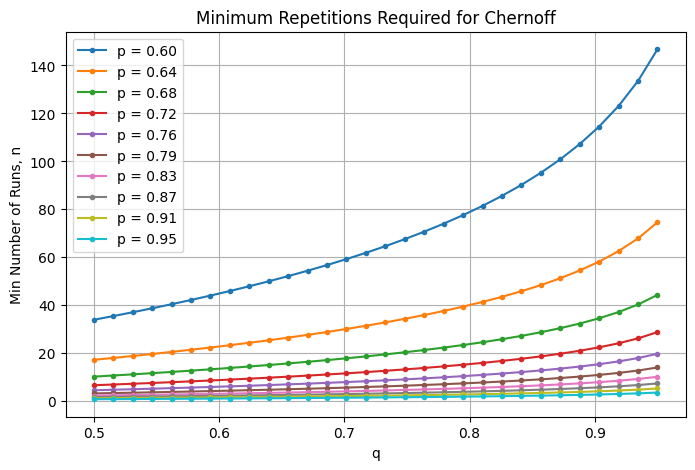

In [130]:
def chernoff_repeat(p, q):
    """Minimum Number repetitions required"""
    return 2*log(1-q)/log(4*p*(1-p))

ps = np.linspace(0.6,0.95,10)
qs = np.linspace(0.5,0.95,30)

plt.figure(figsize=(8, 5))

for p in ps:
    ys = np.array([chernoff_repeat(p, q) for q in qs])
    plt.plot(qs, ys, marker='.', label=f'p = {p:.2f}')

plt.xlabel('q')
plt.ylabel('Min Number of Runs, n')
plt.title('Minimum Repetitions Required for Chernoff')
plt.grid(True)
plt.legend()
plt.show()


## Exact Expression

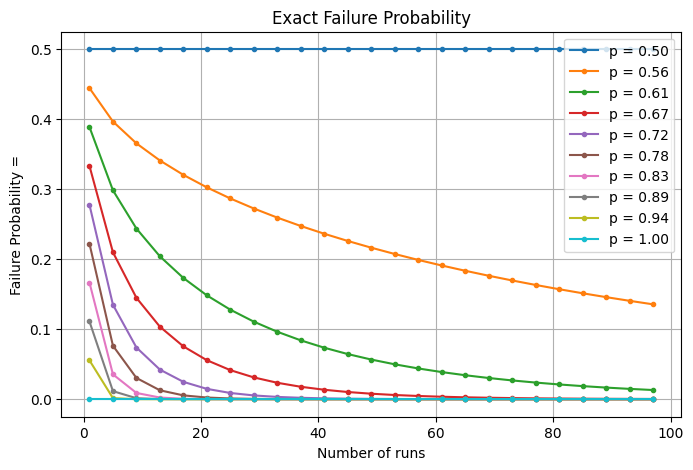

In [131]:
def exact(n, p):
    threshold = n // 2
    # Probability of getting <= floor(n/2) 
    return binom.cdf(threshold, n, p)

ps = np.linspace(0.5,1,10)
n_values = range(1,100,4)   

plt.figure(figsize=(8, 5))

for p in ps:
    ys = [exact(n, p) for n in n_values]
    plt.plot(n_values, ys, marker='.', label=f'p = {p:.2f}')

plt.xlabel('Number of runs')
plt.ylabel('Failure Probability =')
plt.title('Exact Failure Probability')
plt.grid(True)
plt.legend()
plt.show()


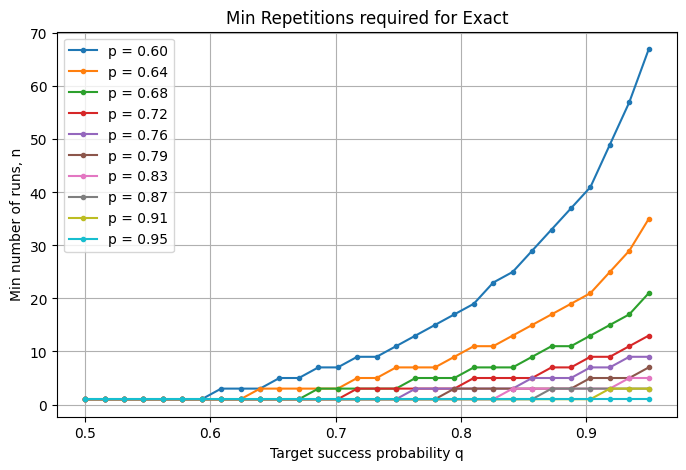

In [132]:
def exact_repeat(p, q):
    for n in range(1, 1000):
        k = (n // 2) + 1  
        prob_correct = 1 - binom.cdf(k - 1, n, p)
        if prob_correct >= q:
            return n
    return None  

ps = np.linspace(0.6,0.95,10)
qs = np.linspace(0.5,0.95,30)

plt.figure(figsize=(8, 5))

for p in ps:
    ys = [exact_repeat(p, q) for q in qs]
    plt.plot(qs, ys, marker='.', label=f'p = {p:.2f}')

plt.xlabel('Target success probability q')
plt.ylabel('Min number of runs, n')
plt.title('Min Repetitions required for Exact')
plt.grid(True)
plt.legend()
plt.show()


## Hoeffding Inequality

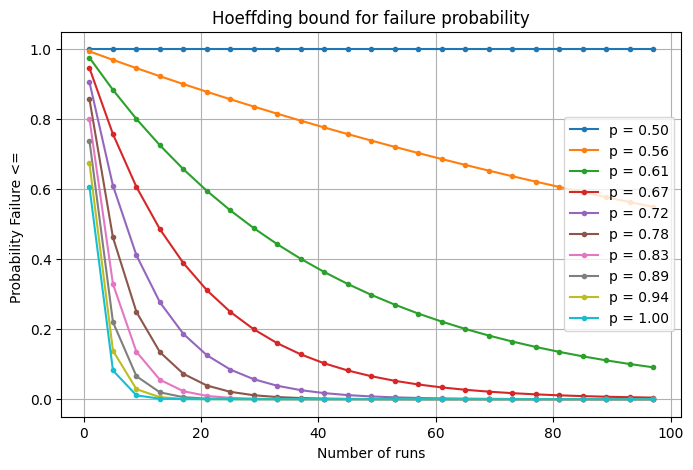

In [133]:
def hoeffding(n, p):
    return exp(-2*n*(p-0.5)**2)

ps = np.linspace(0.5,1,10)
n_values = range(1,100,4)   

plt.figure(figsize=(8, 5))

for p in ps:
    ys = [hoeffding(n, p) for n in n_values]
    plt.plot(n_values, ys, marker='.', label=f'p = {p:.2f}')

plt.xlabel('Number of runs')
plt.ylabel('Probability Failure <= ')
plt.title('Hoeffding bound for failure probability')
plt.grid(True)
plt.legend()
plt.show()

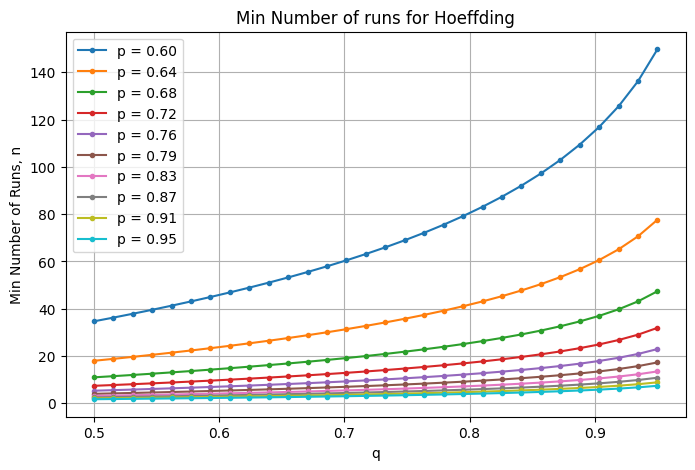

In [134]:
def hoeffding_repeat(p, q):
    return np.log(1 / (1 - q)) / (2 * (p - 0.5)**2)

ps = np.linspace(0.6,0.95,10)
qs = np.linspace(0.5,0.95,30)

plt.figure(figsize=(8, 5))

for p in ps:
    ys = np.array([hoeffding_repeat(p, q) for q in qs])
    plt.plot(qs, ys, marker='.', label=f'p = {p:.2f}')

plt.xlabel('q')
plt.ylabel('Min Number of Runs, n')
plt.title('Min Number of runs for Hoeffding')
plt.grid(True)
plt.legend()
plt.show()

## Chebyshev Inequality

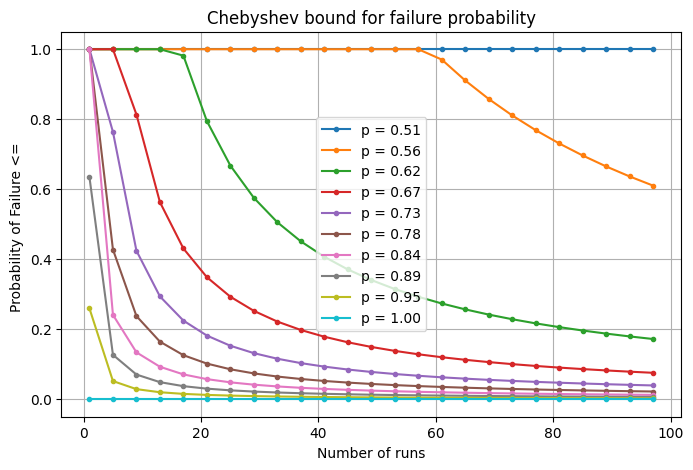

In [135]:
def chebyshev(n, p):
    bound = p * (1 - p) / (n * (p - 0.5)**2)
    return min(1.0, bound)  


ps = np.linspace(0.51,1,10)
n_values = range(1,100,4)   

plt.figure(figsize=(8, 5))

for p in ps:
    ys = [chebyshev(n, p) for n in n_values]
    plt.plot(n_values, ys, marker='.', label=f'p = {p:.2f}')

plt.xlabel('Number of runs')
plt.ylabel('Probability of Failure <= ')
plt.title('Chebyshev bound for failure probability')
plt.grid(True)
plt.legend()
plt.show()

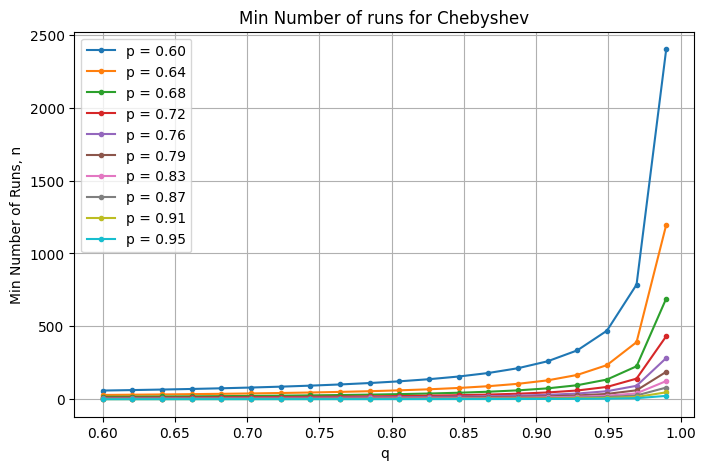

In [138]:
def chebyshev_repeat(p, q):
    return p * (1 - p) / ((p - 0.5)**2 * (1 - q))

ps = np.linspace(0.6,0.95,10)
qs = np.linspace(0.6, 0.99, 20)

plt.figure(figsize=(8, 5))

for p in ps:
    ys = np.array([chebyshev_repeat(p, q) for q in qs])
    plt.plot(qs, ys, marker='.', label=f'p = {p:.2f}')

plt.xlabel('q')
plt.ylabel('Min Number of Runs, n')
plt.title('Min Number of runs for Chebyshev')
plt.grid(True)
plt.legend()
plt.show()

# Comparison

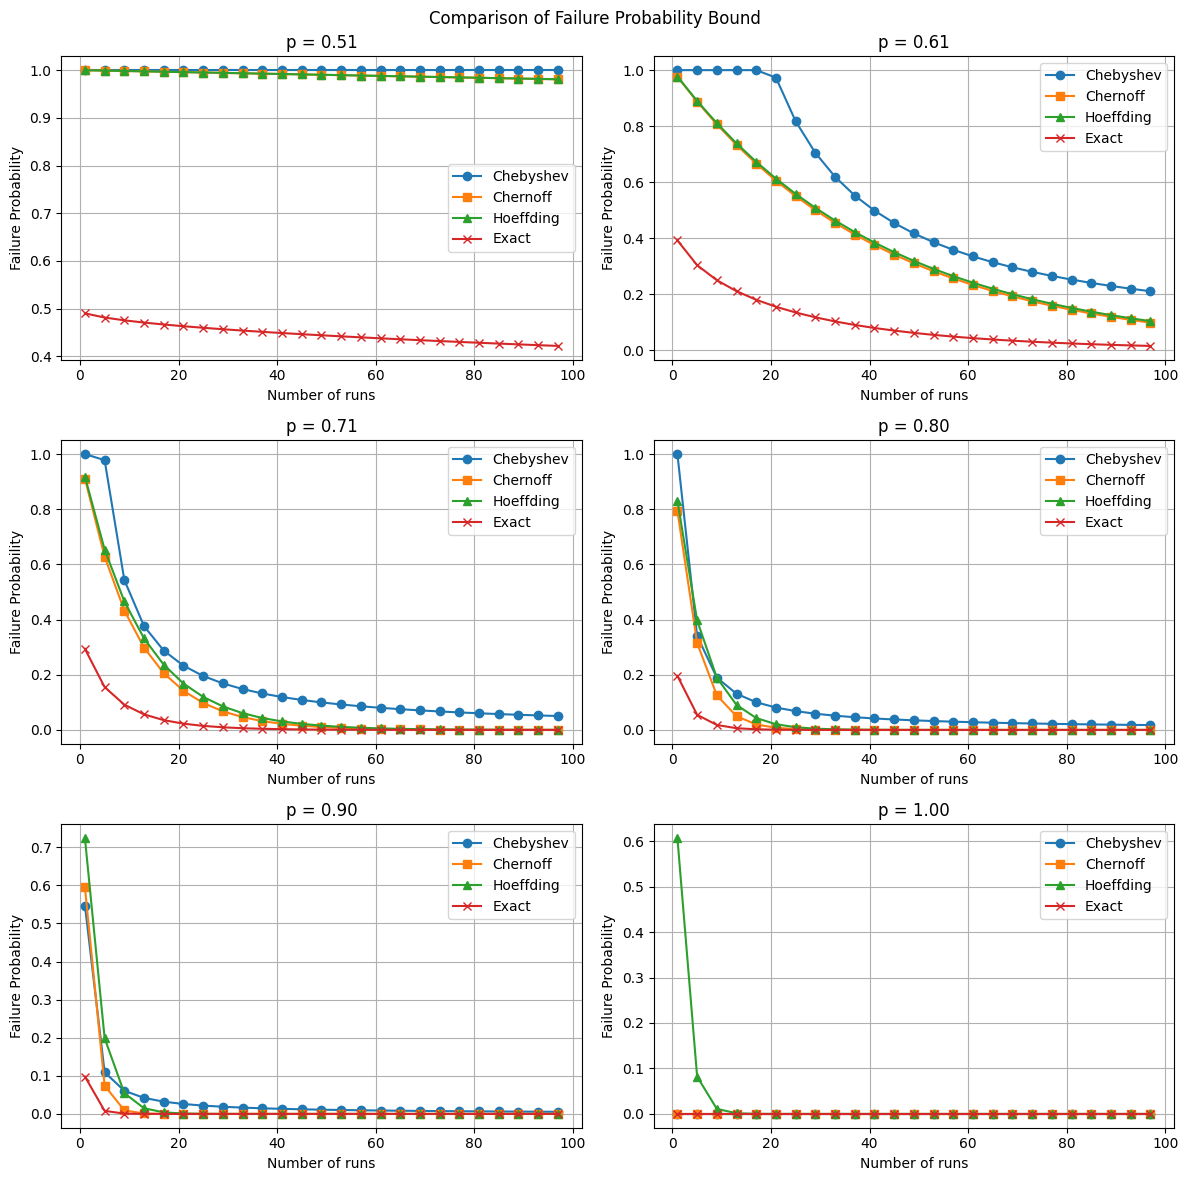

In [153]:
ps = np.linspace(0.51,1,6)
n_values = range(1,100,4)   

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()  

for i, p in enumerate(ps):
    ax = axes[i]
    
    ys_cheb = np.array([chebyshev(n, p) for n in n_values])
    ys_cher = np.array([chernoff(n, p) for n in n_values])
    ys_hoef = np.array([hoeffding(n, p) for n in n_values])
    ys_exact = np.array([exact(n, p) for n in n_values])
    
    ax.plot(n_values, ys_cheb, marker='o', label='Chebyshev')
    ax.plot(n_values, ys_cher, marker='s', label='Chernoff')
    ax.plot(n_values, ys_hoef, marker='^', label='Hoeffding')
    ax.plot(n_values, ys_exact, marker='x', label='Exact')

    ax.set_title(f"p = {p:.2f}")
    ax.set_xlabel('Number of runs')
    ax.set_ylabel('Failure Probability')
    ax.grid(True)
    ax.legend()

fig.suptitle("Comparison of Failure Probability Bound")
plt.tight_layout()
plt.show()

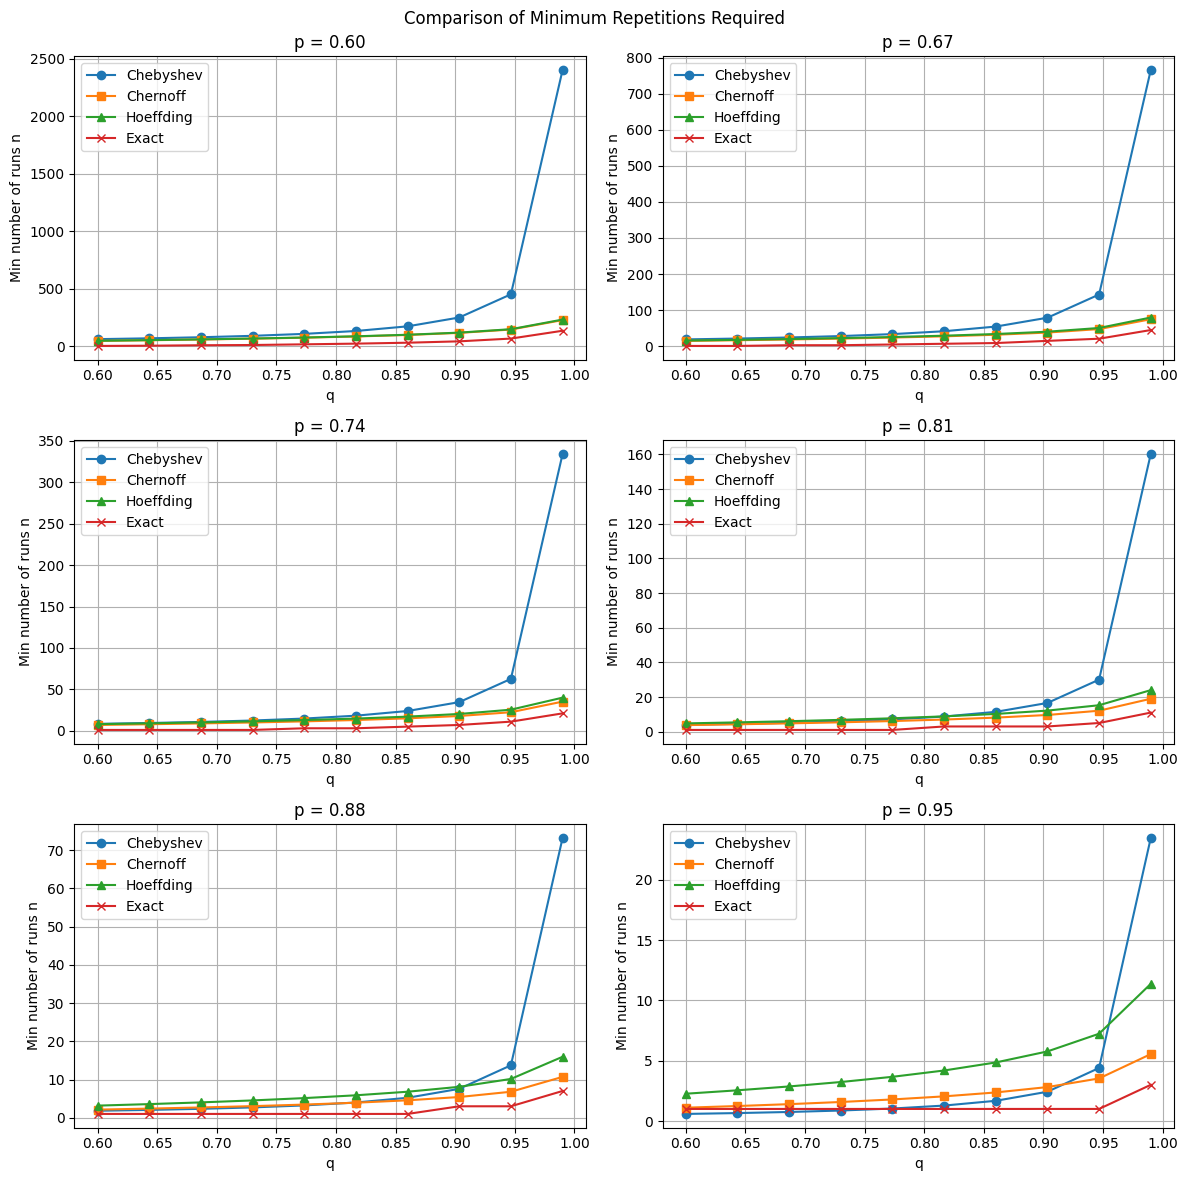

In [154]:
ps = np.linspace(0.6, 0.95, 6)
qs = np.linspace(0.6, 0.99, 10)

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()  

for i, p in enumerate(ps):
    ax = axes[i]
    
    ys_cheb = np.array([chebyshev_repeat(p, q) for q in qs])
    ys_chur = np.array([chernoff_repeat(p, q) for q in qs])
    ys_hoef = np.array([hoeffding_repeat(p, q) for q in qs])
    ys_exact = np.array([exact_repeat(p, q) for q in qs])
    
    ax.plot(qs, ys_cheb, marker='o', label='Chebyshev')
    ax.plot(qs, ys_chur, marker='s', label='Chernoff')
    ax.plot(qs, ys_hoef, marker='^', label='Hoeffding')
    ax.plot(qs, ys_exact, marker='x', label='Exact')

    ax.set_title(f"p = {p:.2f}")
    ax.set_xlabel('q')
    ax.set_ylabel('Min number of runs n')
    ax.grid(True)
    ax.legend()

fig.suptitle("Comparison of Minimum Repetitions Required")
plt.tight_layout()
plt.show()
